In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings; warnings.filterwarnings('ignore')

torch.manual_seed(42); np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


In [4]:
window       = 30
batch        = 32
feature_cols = ['u_wind', 'v_wind', 'temperature_2m', 'total_precipitation',
                'wave_height_lag1', 'wave_height_lag2', 'wave_height_lag3']
target_col   = 'wave_height'

In [5]:
df = pd.read_csv('/content/drive/MyDrive/GEE_exports/nc_coast_final.csv',
                 parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

for lag in [1, 2, 3]:
    df[f'wave_height_lag{lag}'] = df['wave_height'].shift(lag)

df_clean = df[feature_cols + [target_col]].dropna().reset_index(drop=True)

In [6]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(df_clean[feature_cols].values).astype(np.float32)
y_scaled = scaler_y.fit_transform(df_clean[[target_col]].values).ravel().astype(np.float32)

def make_windows(X, y, w):
    Xs, ys = [], []
    for i in range(w, len(X)):
        Xs.append(X[i-w:i]); ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_win, y_win = make_windows(X_scaled, y_scaled, window)

In [7]:
n = len(X_win)
train_end, val_end = int(0.70*n), int(0.85*n)
X_train, y_train = X_win[:train_end],        y_win[:train_end]
X_val,   y_val   = X_win[train_end:val_end], y_win[train_end:val_end]
X_test,  y_test  = X_win[val_end:],          y_win[val_end:]

In [8]:
class WaveDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X); self.y = torch.tensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(WaveDataset(X_train, y_train), batch_size=batch, shuffle=True)
val_loader   = DataLoader(WaveDataset(X_val,   y_val),   batch_size=batch)
test_loader  = DataLoader(WaveDataset(X_test,  y_test),  batch_size=batch)

In [9]:
class WaveLSTM(nn.Module):
    def __init__(self, input_size, hidden=64, layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, num_layers=layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

model = WaveLSTM(input_size=len(feature_cols)).to(device)

In [10]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
history = {'train': [], 'val': []}
best_val, best_state = float('inf'), None
patience_counter = 0
early_stop = 20
epochs = 100

for epoch in range(1, epochs+1):
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            val_losses.append(criterion(model(xb.to(device)), yb.to(device)).item())

    tl, vl = np.mean(train_losses), np.mean(val_losses)
    history['train'].append(tl); history['val'].append(vl)
    scheduler.step(vl)

    if vl < best_val:
        best_val = vl
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= early_stop:
            print(f"Early stopping at epoch {epoch}")
            break

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}/{epochs}  train={tl:.4f}  val={vl:.4f}")

model.load_state_dict(best_state)
print(f"Best val loss: {best_val:.4f}")


Epoch  10/100  train=0.6404  val=1.0465
Epoch  20/100  train=0.5752  val=0.9656
Epoch  30/100  train=0.5669  val=0.9392
Epoch  40/100  train=0.5172  val=0.9431
Epoch  50/100  train=0.4917  val=0.9527
Epoch  60/100  train=0.5006  val=0.9497
Early stopping at epoch 61
Best val loss: 0.9305


In [11]:
def eval_np(model, X, y_sc):
    model.eval()
    with torch.no_grad():
        p = model(torch.tensor(X).to(device)).cpu().numpy()
    p_m = scaler_y.inverse_transform(p.reshape(-1,1)).ravel()
    t_m = scaler_y.inverse_transform(y_sc.reshape(-1,1)).ravel()
    return np.sqrt(mean_squared_error(t_m, p_m)), r2_score(t_m, p_m)

base_rmse, base_r2 = eval_np(model, X_test, y_test)
print(f"Baseline  RMSE={base_rmse:.4f} m  R²={base_r2:.4f}")

Baseline  RMSE=0.2864 m  R²=0.2540


In [12]:
perm_results = {}
for feat_idx, feat_name in enumerate(feature_cols):
    X_perm = X_test.copy()
    X_perm[:, :, feat_idx] = X_perm[np.random.permutation(len(X_perm)), :, feat_idx]
    rmse_p, _ = eval_np(model, X_perm, y_test)
    perm_results[feat_name] = rmse_p - base_rmse
    print(f"  {feat_name:30s}  ΔRMSE={perm_results[feat_name]:+.4f}")

  u_wind                          ΔRMSE=+0.0919
  v_wind                          ΔRMSE=+0.0383
  temperature_2m                  ΔRMSE=+0.0185
  total_precipitation             ΔRMSE=-0.0008
  wave_height_lag1                ΔRMSE=-0.0024
  wave_height_lag2                ΔRMSE=-0.0057
  wave_height_lag3                ΔRMSE=+0.0003


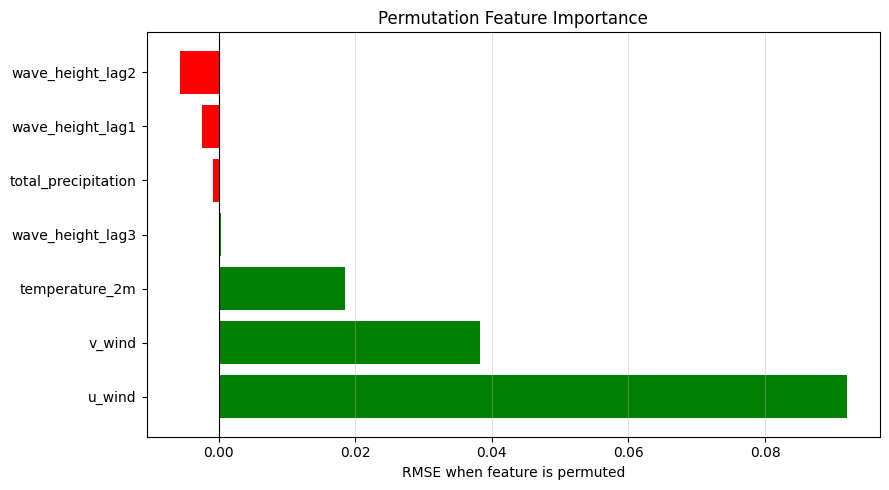

In [13]:
order  = np.argsort(list(perm_results.values()))[::-1]
names  = [list(perm_results.keys())[i] for i in order]
deltas = [list(perm_results.values())[i] for i in order]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(names, deltas, color=['green' if d > 0 else 'red' for d in deltas])
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('RMSE when feature is permuted')
ax.set_title('Permutation Feature Importance')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout(); plt.show()

In [15]:
def train_ablation(X_all, y_all, keep_indices, epochs=40):
    X_sub = X_all[:, :, keep_indices]
    n = len(X_sub)
    t, v = int(0.70*n), int(0.85*n)
    tr = DataLoader(WaveDataset(X_sub[:t],  y_all[:t]),  batch_size=batch, shuffle=True)
    va = DataLoader(WaveDataset(X_sub[t:v], y_all[t:v]), batch_size=batch)
    te_X, te_y = X_sub[v:], y_all[v:]

    m = WaveLSTM(input_size=len(keep_indices)).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-3)
    best_v, best_s = float('inf'), None

    for ep in range(1, epochs+1):
        m.train()
        for xb, yb in tr:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); criterion(m(xb), yb).backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0); opt.step()
        m.eval()
        vl = np.mean([criterion(m(xb.to(device)), yb.to(device)).item() for xb, yb in va])
        if vl < best_v: best_v = vl; best_s = {k: v.cpu().clone() for k, v in m.state_dict().items()}

    m.load_state_dict(best_s); m.eval()
    with torch.no_grad():
        p = m(torch.tensor(te_X).to(device)).cpu().numpy()
    p_m = scaler_y.inverse_transform(p.reshape(-1,1)).ravel()
    t_m = scaler_y.inverse_transform(te_y.reshape(-1,1)).ravel()
    return np.sqrt(mean_squared_error(t_m, p_m))

ablation_results = {}
all_idx = list(range(len(feature_cols)))
print("Running ablation...")
for drop_idx, feat_name in enumerate(feature_cols):
    keep = [i for i in all_idx if i != drop_idx]
    rmse = train_ablation(X_win, y_win, keep)
    ablation_results[feat_name] = rmse - base_rmse
    print(f"  Drop {feat_name:30s}  RMSE={ablation_results[feat_name]:+.4f}")

Running ablation...
  Drop u_wind                          RMSE=+0.0417
  Drop v_wind                          RMSE=-0.0048
  Drop temperature_2m                  RMSE=-0.0109
  Drop total_precipitation             RMSE=-0.0139
  Drop wave_height_lag1                RMSE=-0.0094
  Drop wave_height_lag2                RMSE=-0.0166
  Drop wave_height_lag3                RMSE=-0.0148


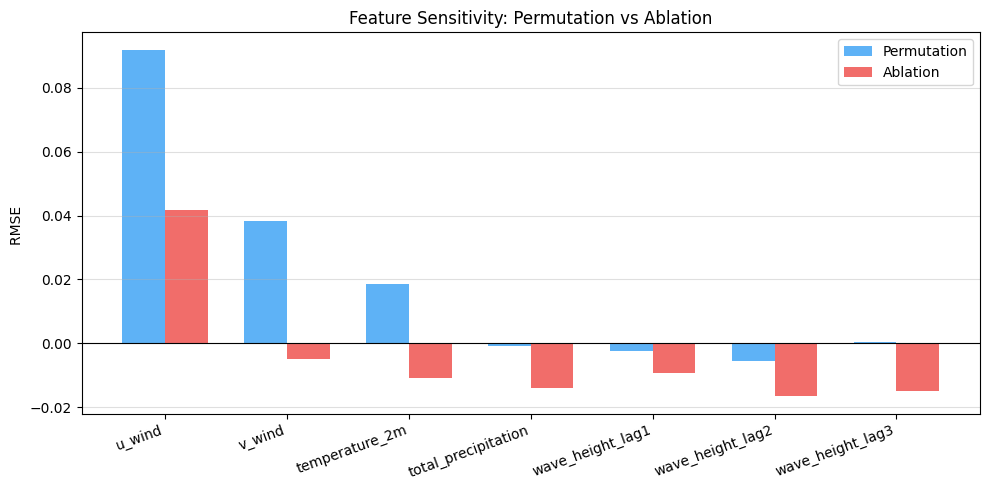


Baseline RMSE: 0.2864 m


In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(feature_cols))
w = 0.35
ax.bar(x - w/2, [perm_results[f]    for f in feature_cols], w, label='Permutation', color='#42A5F5', alpha=0.85)
ax.bar(x + w/2, [ablation_results[f] for f in feature_cols], w, label='Ablation',    color='#EF5350', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(feature_cols, rotation=20, ha='right')
ax.set_ylabel('RMSE '); ax.set_title('Feature Sensitivity: Permutation vs Ablation')
ax.axhline(0, color='black', lw=0.8)
ax.legend(); ax.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()

print(f"\nBaseline RMSE: {base_rmse:.4f} m")